# 🎥 **Giới thiệu**

Bộ dữ liệu gồm gần 7k dòng và 12 đặc trưng:
- `isbn13`: Mã ISBN13
- `isbn10`: Mã ISBN10
- `title`: Tiêu dề sách
- `subtitle`: Tiêu đề phụ
- `authors`: Tác giả
- `categories`: Phân loại
- `thumbnail`: Bìa sách
- `description`: Mô tả
- `published_year`: Năm công bố sách
- `average_rating`: Đánh giá thang đo trung bình
- `num_pages`: Số trang
- `ratings_count`: Lượt đánh giá








# 📁 **Đọc dữ liệu và xem tổng quan dữ liệu**

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [78]:
df = pd.read_csv("books.csv")

In [79]:
df.head()

,isbn13,isbn10,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count
0,9780002005883,0002005883,Gilead,NaN,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0
1,9780002261982,0002261987,Spider's Web,A Novel,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,241.0,5164.0
2,9780006163831,0006163831,The One Tree,NaN,Stephen R. Donaldson,American fiction,http://books.google.com/books/content?id=OmQaw...,Volume Two of Stephen Donaldson's acclaimed se...,1982.0,3.97,479.0,172.0
3,9780006178736,0006178731,Rage of angels,NaN,Sidney Sheldon,Fiction,http://books.google.com/books/content?id=FKo2T...,"A memorable, mesmerizing heroine Jennifer -- b...",1993.0,3.93,512.0,29532.0
4,9780006280897,0006280897,The Four Loves,NaN,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=XhQ5X...,Lewis' work on the nature of love divides love...,2002.0,4.15,170.0,33684.0


# ⚙ **Kiểm tra dữ liệu**

In [80]:
df.shape # In dòng và cột

(6810, 12)

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6810 entries, 0 to 6809
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   isbn13          6810 non-null   int64  
 1   isbn10          6810 non-null   object 
 2   title           6810 non-null   object 
 3   subtitle        2381 non-null   object 
 4   authors         6738 non-null   object 
 5   categories      6711 non-null   object 
 6   thumbnail       6481 non-null   object 
 7   description     6548 non-null   object 
 8   published_year  6804 non-null   float64
 9   average_rating  6767 non-null   float64
 10  num_pages       6767 non-null   float64
 11  ratings_count   6767 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 638.6+ KB


In [82]:
df.describe()

,isbn13,published_year,average_rating,num_pages,ratings_count
count,6.810000e+03,6804.000000,6767.000000,6767.000000,6.767000e+03
mean,9.780677e+12,1998.630364,3.933284,348.181026,2.106910e+04
std,6.068911e+08,10.484257,0.331352,242.376783,1.376207e+05
min,9.780002e+12,1853.000000,0.000000,0.000000,0.000000e+00
25%,9.780330e+12,1996.000000,3.770000,208.000000,1.590000e+02
50%,9.780553e+12,2002.000000,3.960000,304.000000,1.018000e+03
75%,9.780810e+12,2005.000000,4.130000,420.000000,5.992500e+03
max,9.789042e+12,2019.000000,5.000000,3342.000000,5.629932e+06


In [83]:
df.describe(include='object')

,isbn10,title,subtitle,authors,categories,thumbnail,description
count,6810,6810,2381,6738,6711,6481,6548
unique,6810,6398,2009,3780,567,6481,6474
top,9042003405,The Lord of the Rings,A Novel,Agatha Christie,Fiction,http://books.google.com/books/content?id=2lVyR...,No Marketing Blurb
freq,1,11,226,37,2588,1,6


In [84]:
df.isnull().sum() # Kiểm tra dữ liệu thiếu

,0
isbn13,0
isbn10,0
title,0
subtitle,4429
authors,72
categories,99
thumbnail,329
description,262
published_year,6
average_rating,43


In [85]:
df.duplicated().sum() # Kiểm tra dữ liệu trùng

np.int64(0)

# 🧪 **Tiền xử lý dữ liệu**

In [86]:
df['missing_description'] = np.where(df['description'].isnull(), 1, 0) # Thêm cột xem phần mô tả có null hay không
df['age_of_books'] = 2026 - df['published_year'] # Thêm cột tuổi sách

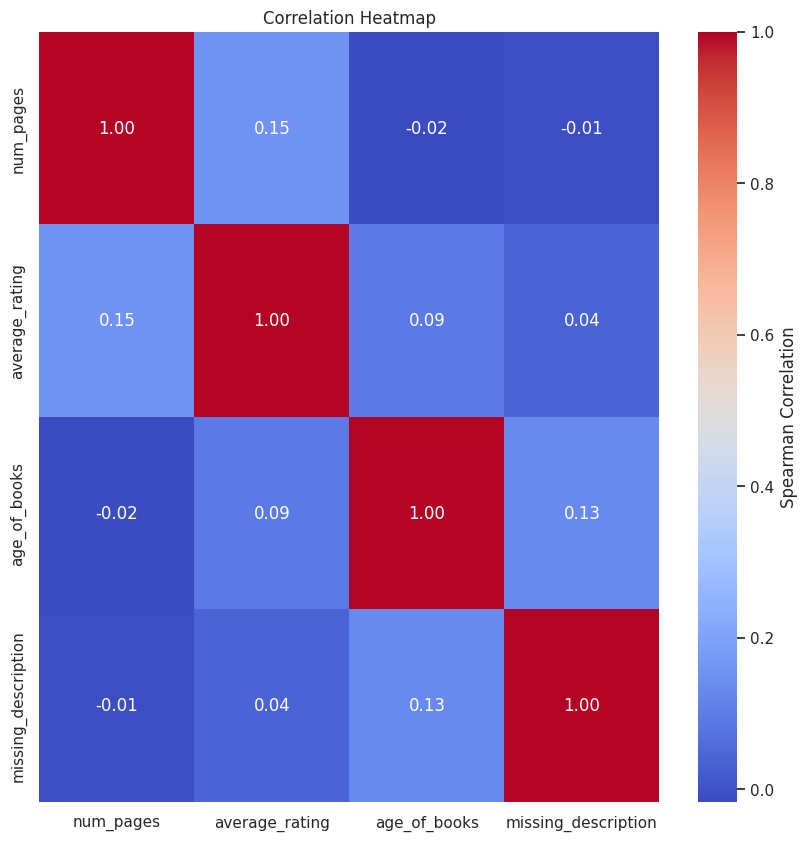

In [87]:
# Phân loại các đặc trưng
columns_is_interest = ['num_pages', 'average_rating', 'age_of_books', 'missing_description']

# Tạo correlaton maxtrix (ma trận tương quan)
corr_matrix = df[columns_is_interest].corr(method='spearman')

sns.set_theme(style="white")
plt.figure(figsize=(10, 10))

heatmap = sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f",
                      cbar_kws={"label": "Spearman Correlation"})

heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':12})
plt.show()

**Nhận xét**

- Việc thiếu mô tả không ảnh hưởng nhiều đến với số trang hay tỷ lệ đánh giá

In [88]:
df_missing = df[~(df['description'].isna()) &
   ~(df['num_pages'].isna()) &
   ~(df['average_rating'].isna()) &
   ~(df['published_year'].isna())
   ] # Loại bỏ các dòng có dữ liệu thiếu

In [89]:
df_missing # Không có missing

,isbn13,isbn10,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count,missing_description,age_of_books
0,9780002005883,0002005883,Gilead,NaN,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0,0,22.0
1,9780002261982,0002261987,Spider's Web,A Novel,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,241.0,5164.0,0,26.0
2,9780006163831,0006163831,The One Tree,NaN,Stephen R. Donaldson,American fiction,http://books.google.com/books/content?id=OmQaw...,Volume Two of Stephen Donaldson's acclaimed se...,1982.0,3.97,479.0,172.0,0,44.0
3,9780006178736,0006178731,Rage of angels,NaN,Sidney Sheldon,Fiction,http://books.google.com/books/content?id=FKo2T...,"A memorable, mesmerizing heroine Jennifer -- b...",1993.0,3.93,512.0,29532.0,0,33.0
4,9780006280897,0006280897,The Four Loves,NaN,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=XhQ5X...,Lewis' work on the nature of love divides love...,2002.0,4.15,170.0,33684.0,0,24.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6803,9788173031014,8173031010,Journey to the East,NaN,Hermann Hesse,Adventure stories,http://books.google.com/books/content?id=rq6JP...,This book tells the tale of a man who goes on ...,2002.0,3.70,175.0,24.0,0,24.0
6804,9788179921623,817992162X,The Monk Who Sold His Ferrari: A Fable About F...,NaN,Robin Sharma,Health & Fitness,http://books.google.com/books/content?id=c_7mf...,"Wisdom to Create a Life of Passion, Purpose, a...",2003.0,3.82,198.0,1568.0,0,23.0
6805,9788185300535,8185300534,I Am that,Talks with Sri Nisargadatta Maharaj,Sri Nisargadatta Maharaj;Sudhakar S. Dikshit,Philosophy,http://books.google.com/books/content?id=Fv_JP...,This collection of the timeless teachings of o...,1999.0,4.51,531.0,104.0,0,27.0
6808,9789027712059,9027712050,The Berlin Phenomenology,NaN,Georg Wilhelm Friedrich Hegel,History,http://books.google.com/books/content?id=Vy7Sk...,Since the three volume edition ofHegel's Philo...,1981.0,0.00,210.0,0.0,0,45.0


In [90]:
df_missing['categories'].value_counts().reset_index().sort_values("count", ascending=False) # Số lượng các thể loại sách

,categories,count
0,Fiction,2523
1,Juvenile Fiction,534
2,Biography & Autobiography,391
3,History,258
4,Literary Criticism,164
...,...,...
519,"Adventure stories, English",1
518,Germany,1
517,Egypt,1
516,Apartments,1


In [91]:
df_missing['word_count'] = df_missing['description'].str.split().str.len() # Đếm số lượng từ có trong mô tả

In [92]:
df_missing.loc[df_missing['word_count'].between(1, 4), 'description'] # Chọn lọc ra các cột mô tả có từ 1 đến 4 từ trong 1 câu

,description
6,Donation.
11,Fantasy-roman.
748,Includes bibliographical references.
770,Bound For Oregon (PB)
775,No Marketing Blurb
812,No Marketing Blurb
857,First published in 1813.
944,Edited by Maurice Hindle.
953,DEFOE/ROBINSON CRUSOE (BC)
954,Edited by John Carey.


In [93]:
df_missing.loc[df_missing['word_count'].between(5, 14), 'description'] # Chọn lọc ra các cột mô tả có từ 5 đến 14 từ trong 1 câu

,description
2,Volume Two of Stephen Donaldson's acclaimed se...
38,Koko is Peter Straub's foray into the psycholo...
70,A matter of life and death - and the Throne of...
77,Nonsense rhyming story. 4 yrs+
84,A study guide for the novel There's a Boy in t...
...,...
6715,The first comprehensive guide to addressing Na...
6726,Presents two complete novels from Henry James.
6757,Audio Book- unabriged on CD
6776,Raymond Chandler meets The Exorcist. Classic n...


In [94]:
df_missing.loc[df_missing['word_count'].between(15, 24), 'description'] # Chọn lọc ra các cột mô tả có từ 15 đến 24 từ trong 1 câu

,description
10,One of Sidney Sheldon's most popular and bests...
32,Tells the story of three generations of Chines...
36,A magical and fantastic collection of early st...
57,A young drifter finds more than he bargained f...
68,A new 'The Doors of Perception' for the 21st c...
...,...
6767,Everything from the fingerprints of the gods t...
6782,Displays one of America's leading physicist's ...
6783,Basics Illustration 01: Thinking Visually expl...
6789,Provides an introduction to the American artis...


In [95]:
df_missing.loc[df_missing['word_count'].between(25, 34), 'description'] # Chọn lọc ra các cột mô tả có từ 25 đến 34 từ trong 1 câu

,description
9,Kate Blackwell is an enigma and one of the mos...
14,"Available in the U.S. for the first time, this..."
20,"It is 1937, and Charles Ashworth, a Canon to t..."
21,Reissue of the author's most famous and well-l...
46,No one believes a little girl when she insists...
...,...
6760,"Joel, an English teacher, has never really lik..."
6766,Discusses the historical and intellectual back...
6775,Presents nearly one thousand recipes--from app...
6779,Edited by the creator and executive producer o...


In [100]:
"""
Logic: Nếu title hay subtitle không null thì lấy chúng gộp lại cách nhau bằng :
còn đều không null thì chỉ lấy title hoặc subtitie thay thế
"""

df_missing_25_words = df_missing.loc[df_missing['word_count'] >= 25] # Chọn lọc dataset có mô tả hữu dụng

df_missing_25_words['title_and_subtitle'] = (
    np.where(df_missing_25_words['subtitle'].isna(), df_missing_25_words['title'],
             df_missing_25_words[['title', 'subtitle']].astype(str).agg(": ".join, axis=1)) # Gộp title và subtitle thành 1
)

df_missing_25_words['tagged_description'] = df_missing_25_words[['isbn13', 'description']].astype(str).agg(" ".join, axis=1) # Gộp isbn13 và description

In [101]:
df_missing_25_words.columns

Index(['isbn13', 'isbn10', 'title', 'subtitle', 'authors', 'categories',
       'thumbnail', 'description', 'published_year', 'average_rating',
       'num_pages', 'ratings_count', 'missing_description', 'age_of_books',
       'word_count', 'title_and_subtitle', 'tagged_description'],
      dtype='object')

In [102]:
(
    df_missing_25_words
    .drop(columns=['missing_description', 'subtitle', 'age_of_books', 'word_count'], axis=1)
    .to_csv('books_cleaned.csv', index=False)
)